# Clasificación: TMDB Movie Dataset

## Objetivo
Se implementan dos tareas de clasificación sobre el dataset de películas TMDB:

**Clasificación 1 — `highly_rated` (binaria)**
Predecir si una película será bien valorada (vote_average ≥ 7.0)
basándose en características de producción y metadata.

**Clasificación 2 — `success_category` (multiclase, 4 clases)**
Predecir el tipo de éxito de una película combinando rating y popularidad:
- Success: bien valorada Y popular
- Critically Acclaimed: bien valorada, no popular
- Commercial Hit: popular, no bien valorada
- Standard: ninguna de las anteriores

## Algoritmos
- Gaussian Naive Bayes
- Red Bayesiana (pgmpy)
- Random Forest

## Validación
Validación cruzada estratificada 10-fold (como indicado en clase)
F1-Score como métrica principal dado el desbalance de clases.

In [1]:
#!pip install pgmpy 

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,ConfusionMatrixDisplay, f1_score,precision_score, recall_score, accuracy_score)
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120 #Matplotlib images resolution
print("Librerías cargadas correctamente.")

ImportError: cannot import name 'DiscreteMLE' from 'pgmpy.estimators' (C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pgmpy\estimators\__init__.py)

In [3]:
ds = load_dataset("pauguzman/tmdb_mineria_datos_processed")
df = ds['train'].to_pandas()

print(f"Dataset: {df.shape[0]:,} películas | {df.shape[1]} variables")
print(f"\nColumnas disponibles:\n{list(df.columns)}")

Dataset: 116,929 películas | 23 variables

Columnas disponibles:
['id', 'title', 'vote_average', 'vote_count', 'release_date', 'runtime', 'adult', 'original_language', 'overview', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords', 'release_year', 'duration_bin', 'highly_rated', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5']


In [4]:
# Codificar original_language (top 10 idiomas + "other")
top_langs = df['original_language'].value_counts().nlargest(10).index
df['lang_encoded'] = df['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)
le = LabelEncoder()
df['lang_encoded'] = le.fit_transform(df['lang_encoded'])

# adult a entero
df['adult_int'] = df['adult'].astype(int)

# Features base — sin vote_average, sin popularity, sin highly_rated
# (estas se usan para construir los targets)
FEATURES = ['vote_count', 'runtime', 'release_year', 'adult_int', 'lang_encoded']

print(f"Features seleccionadas: {FEATURES}")
print(f"Registros sin nulos: {df[FEATURES].dropna().shape[0]:,}")

Features seleccionadas: ['vote_count', 'runtime', 'release_year', 'adult_int', 'lang_encoded']
Registros sin nulos: 116,929


── Target 1: highly_rated ──────────────────────────────
highly_rated
0    0.832
1    0.168
Name: proportion, dtype: float64

── Target 2: success_category ──────────────────────────
success_category
Standard                0.642
Commercial Hit          0.190
Critically Acclaimed    0.108
Success                 0.060
Name: proportion, dtype: float64


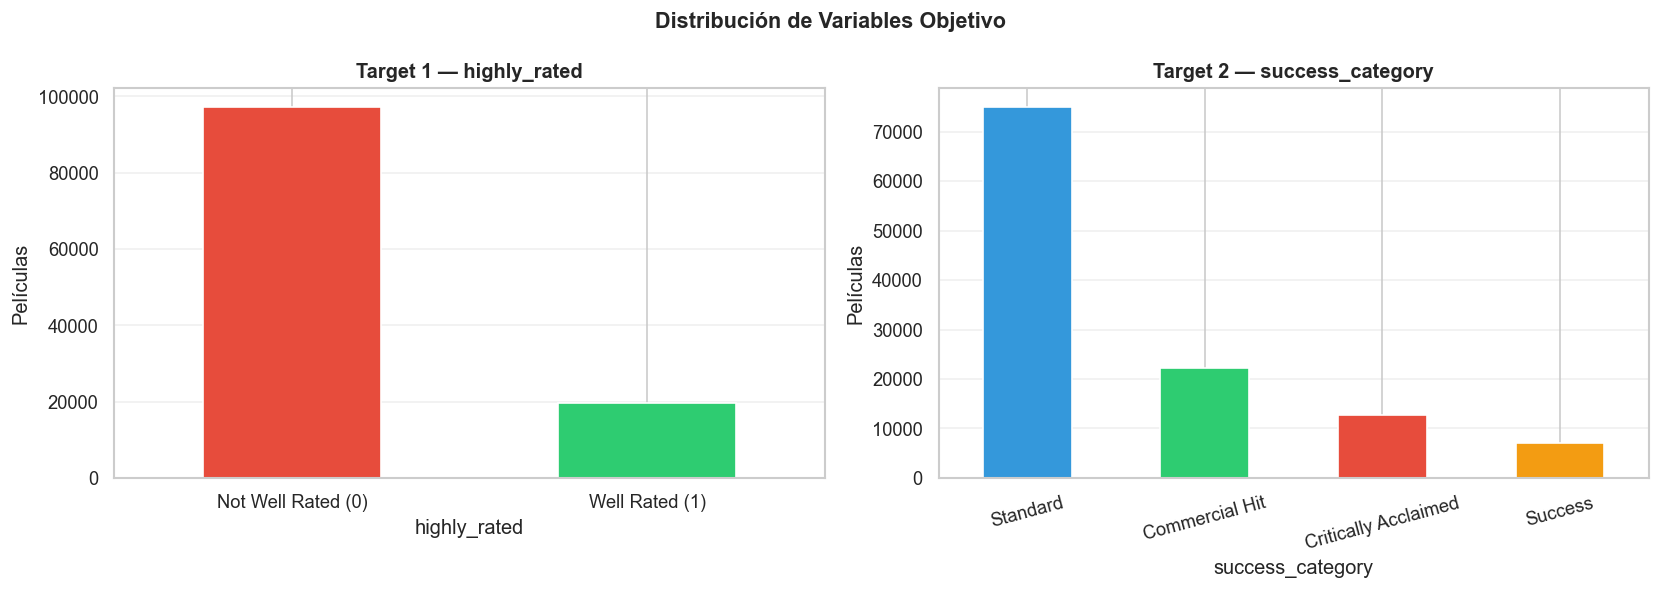

In [ ]:
# ── Target 1: highly_rated (ya existe) ───────────────────────────────────────

# ── Target 2: success_category ───────────────────────────────────────────────
pop_threshold = df['popularity'].quantile(0.75)

# Fix: usar default='' y dtype explícito para numpy 2.0+
conditions = [
    (df['highly_rated'] == 1) & (df['popularity'] > pop_threshold),
    (df['highly_rated'] == 1) & (df['popularity'] <= pop_threshold),
    (df['highly_rated'] == 0) & (df['popularity'] > pop_threshold),
    (df['highly_rated'] == 0) & (df['popularity'] <= pop_threshold),
]
choices = ['Success', 'Critically Acclaimed', 'Commercial Hit', 'Standard']
df['success_category'] = np.select(conditions, choices, default='Standard').astype(str)

# Distribuciones
print("── Target 1: highly_rated ──────────────────────────────")
print(df['highly_rated'].value_counts(normalize=True).round(3))

print("\n── Target 2: success_category ──────────────────────────")
print(df['success_category'].value_counts(normalize=True).round(3))

# Visualización distribución targets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['highly_rated'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'],
    edgecolor='white', rot=0
)
axes[0].set_title('Target 1 — highly_rated', fontweight='bold')
axes[0].set_xticklabels(['Not Well Rated (0)', 'Well Rated (1)'])
axes[0].set_ylabel('Películas')
axes[0].grid(alpha=0.3, axis='y')

df['success_category'].value_counts().plot(
    kind='bar', ax=axes[1], color=['#3498db','#2ecc71','#e74c3c','#f39c12'],
    edgecolor='white', rot=15
)
axes[1].set_title('Target 2 — success_category', fontweight='bold')
axes[1].set_ylabel('Películas')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Distribución de Variables Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
df_model = df[FEATURES + ['highly_rated', 'success_category']].dropna().reset_index(drop=True)

X = df_model[FEATURES].values
y1 = df_model['highly_rated'].values           # binaria
y2 = df_model['success_category'].values       # multiclase string

# Encodear y2 para sklearn
le_success = LabelEncoder()
y2_enc = le_success.fit_transform(y2)
CLASS_NAMES = le_success.classes_

print(f"Registros para modelado: {len(X):,}")
print(f"Clases success_category: {CLASS_NAMES}")

Registros para modelado: 116,929
Clases success_category: ['Commercial Hit' 'Critically Acclaimed' 'Standard' 'Success']


In [9]:
def evaluar_cv(nombre, modelo, X, y, cv=10, promedio='weighted'):
    """
    Validación cruzada estratificada 10-fold.
    promedio='binary' para clasificación binaria,
    promedio='weighted' para multiclase.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    # sklearn no acepta 'precision_binary' — para binario usa 'precision' sin sufijo
    if promedio == 'binary':
        scoring = {
            'accuracy':  'accuracy',
            'precision': 'precision',
            'recall':    'recall',
            'f1':        'f1',
        }
    else:
        scoring = {
            'accuracy':  'accuracy',
            'precision': f'precision_{promedio}',
            'recall':    f'recall_{promedio}',
            'f1':        f'f1_{promedio}',
        }

    res = cross_validate(modelo, X, y, cv=skf,
                         scoring=scoring, return_train_score=False)

    metricas = {
        'Modelo':    nombre,
        'Accuracy':  round(res['test_accuracy'].mean(),  4),
        'Precision': round(res['test_precision'].mean(), 4),
        'Recall':    round(res['test_recall'].mean(),    4),
        'F1-Score':  round(res['test_f1'].mean(),        4),
    }

    print(f"\n{'─'*55}")
    print(f"  {nombre}")
    print(f"{'─'*55}")
    for k, v in metricas.items():
        if k != 'Modelo':
            print(f"   {k:12}: {v:.4f}")

    return metricas

In [10]:
print("═"*55)
print("  CLASIFICACIÓN 1: highly_rated")
print("═"*55)

nb1 = GaussianNB()
res_nb1 = evaluar_cv("Naive Bayes — highly_rated", nb1, X, y1, promedio='binary')

═══════════════════════════════════════════════════════
  CLASIFICACIÓN 1: highly_rated
═══════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  Naive Bayes — highly_rated
───────────────────────────────────────────────────────
   Accuracy    : 0.8285
   Precision   : 0.4307
   Recall      : 0.0673
   F1-Score    : 0.1163


In [12]:
rf1 = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
res_rf1 = evaluar_cv("Random Forest — highly_rated", rf1, X, y1, promedio='binary')


───────────────────────────────────────────────────────
  Random Forest — highly_rated
───────────────────────────────────────────────────────
   Accuracy    : 0.7390
   Precision   : 0.3378
   Recall      : 0.5770
   F1-Score    : 0.4261


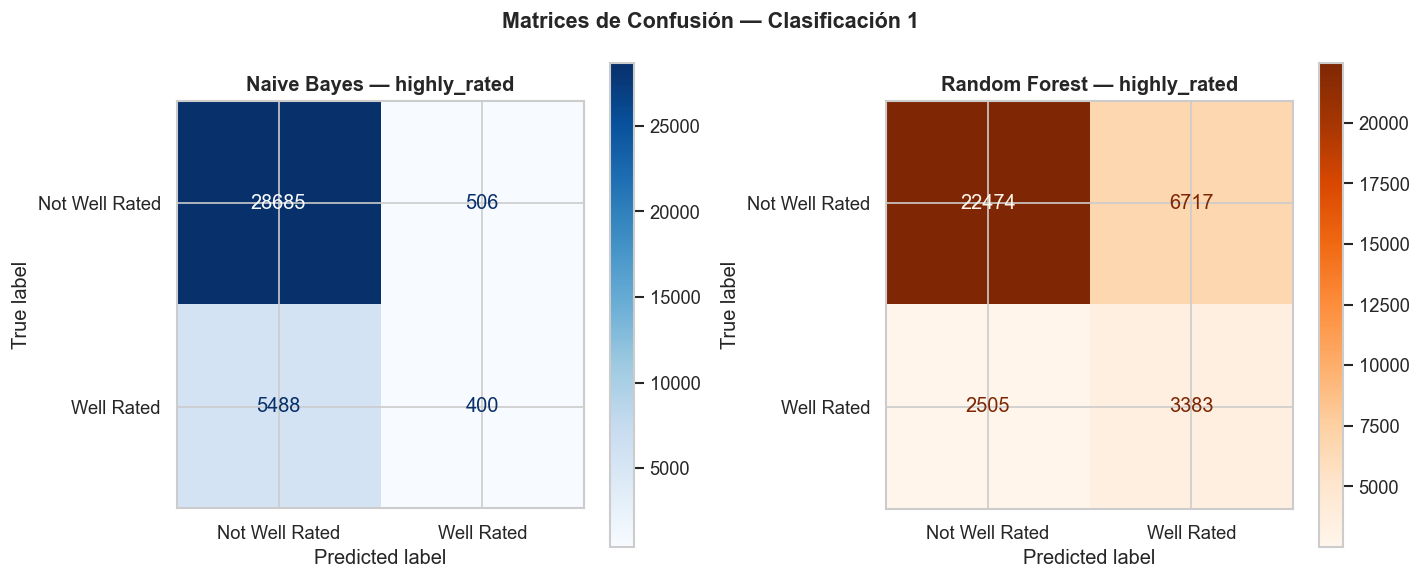


Classification Report — Naive Bayes:
                precision    recall  f1-score   support

Not Well Rated       0.84      0.98      0.91     29191
    Well Rated       0.44      0.07      0.12      5888

      accuracy                           0.83     35079
     macro avg       0.64      0.53      0.51     35079
  weighted avg       0.77      0.83      0.77     35079


Classification Report — Random Forest:
                precision    recall  f1-score   support

Not Well Rated       0.90      0.77      0.83     29191
    Well Rated       0.33      0.57      0.42      5888

      accuracy                           0.74     35079
     macro avg       0.62      0.67      0.63     35079
  weighted avg       0.80      0.74      0.76     35079



In [13]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y1, test_size=0.3, random_state=42, stratify=y1
)

# Naive Bayes
nb1_vis = GaussianNB().fit(X_tr, y_tr)
y_pred_nb1 = nb1_vis.predict(X_te)

# Random Forest
rf1_vis = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
).fit(X_tr, y_tr)
y_pred_rf1 = rf1_vis.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_nb1,
    display_labels=['Not Well Rated', 'Well Rated'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Naive Bayes — highly_rated', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_rf1,
    display_labels=['Not Well Rated', 'Well Rated'],
    cmap='Oranges', ax=axes[1]
)
axes[1].set_title('Random Forest — highly_rated', fontweight='bold')

plt.suptitle('Matrices de Confusión — Clasificación 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report — Naive Bayes:")
print(classification_report(y_te, y_pred_nb1,
      target_names=['Not Well Rated', 'Well Rated']))

print("\nClassification Report — Random Forest:")
print(classification_report(y_te, y_pred_rf1,
      target_names=['Not Well Rated', 'Well Rated']))

C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(



Red Bayesiana — highly_rated (muestra 5,000):
   Accuracy    : 0.8338
   Precision   : 0.0000
   Recall      : 0.0000
   F1-Score    : 0.0000


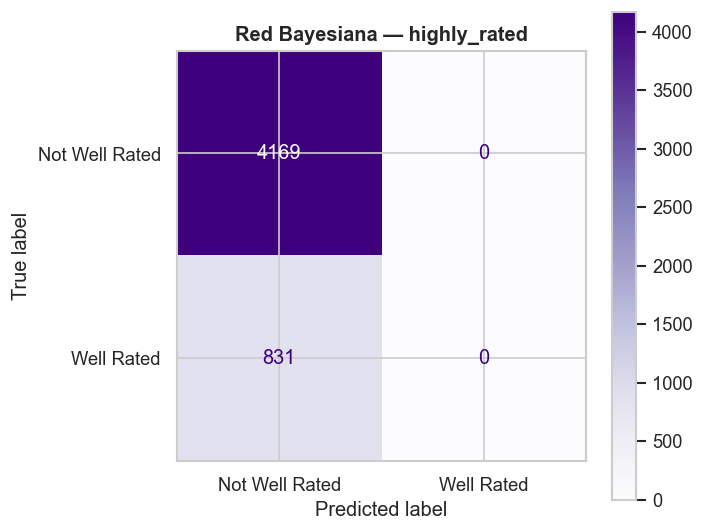

In [26]:
from pgmpy.estimators.MLE import MaximumLikelihoodEstimator as MLE_Estimator
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination

# Discretizar features para pgmpy
disc1 = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
X_disc1 = disc1.fit_transform(X).astype(int)

df_bn1 = pd.DataFrame(X_disc1, columns=[f'{c}_bin' for c in FEATURES])
df_bn1['highly_rated'] = y1

# Estructura causal: todas las features apuntan al target
# vote_count → release_year captura que películas más recientes tienen más votos
estructura_bn1 = [
    ('vote_count_bin',   'highly_rated'),
    ('runtime_bin',      'highly_rated'),
    ('release_year_bin', 'highly_rated'),
    ('adult_int_bin',    'highly_rated'),
    ('lang_encoded_bin', 'highly_rated'),
    ('vote_count_bin',   'release_year_bin'),
]

from pgmpy.parameter_estimator import DiscreteMLE

bn1 = DiscreteBayesianNetwork(estructura_bn1)
bn1.fit(df_bn1, estimator=DiscreteMLE())
infer1 = VariableElimination(bn1)

def predecir_bn(infer, feature_cols, X_disc, target, umbral=0.5):
    preds = []
    for fila in X_disc:
        evidencia = {f'{col}_bin': int(val)
                     for col, val in zip(feature_cols, fila)}
        try:
            q = infer.query([target], evidence=evidencia, show_progress=False)
            prob_pos = q.values[-1]
            preds.append(1 if prob_pos >= umbral else 0)
        except Exception:
            preds.append(0)
    return np.array(preds)

# Muestra 5,000 por costo computacional de inferencia exacta
np.random.seed(42)
idx_s = np.random.choice(len(y1), size=5000, replace=False)
y_pred_bn1 = predecir_bn(infer1, FEATURES, X_disc1[idx_s], 'highly_rated')
y_s1 = y1[idx_s]

res_bn1 = {
    'Modelo':    'Red Bayesiana — highly_rated',
    'Accuracy':  round(accuracy_score(y_s1,  y_pred_bn1), 4),
    'Precision': round(precision_score(y_s1, y_pred_bn1, zero_division=0), 4),
    'Recall':    round(recall_score(y_s1,    y_pred_bn1, zero_division=0), 4),
    'F1-Score':  round(f1_score(y_s1,        y_pred_bn1, zero_division=0), 4),
}

print("\nRed Bayesiana — highly_rated (muestra 5,000):")
for k, v in res_bn1.items():
    if k != 'Modelo':
        print(f"   {k:12}: {v:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_s1, y_pred_bn1,
    display_labels=['Not Well Rated', 'Well Rated'],
    cmap='Purples', ax=ax
)
ax.set_title('Red Bayesiana — highly_rated', fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
print("═"*55)
print("  CLASIFICACIÓN 2: success_category")
print("═"*55)

nb2 = GaussianNB()
res_nb2 = evaluar_cv("Naive Bayes — success_category", nb2, X, y2_enc, promedio='weighted')

═══════════════════════════════════════════════════════
  CLASIFICACIÓN 2: success_category
═══════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  Naive Bayes — success_category
───────────────────────────────────────────────────────
   Accuracy    : 0.7014
   Precision   : 0.6398
   Recall      : 0.7014
   F1-Score    : 0.6220


In [28]:
rf2 = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
res_rf2 = evaluar_cv("Random Forest — success_category", rf2, X, y2_enc, promedio='weighted')


───────────────────────────────────────────────────────
  Random Forest — success_category
───────────────────────────────────────────────────────
   Accuracy    : 0.6477
   Precision   : 0.7405
   Recall      : 0.6477
   F1-Score    : 0.6789


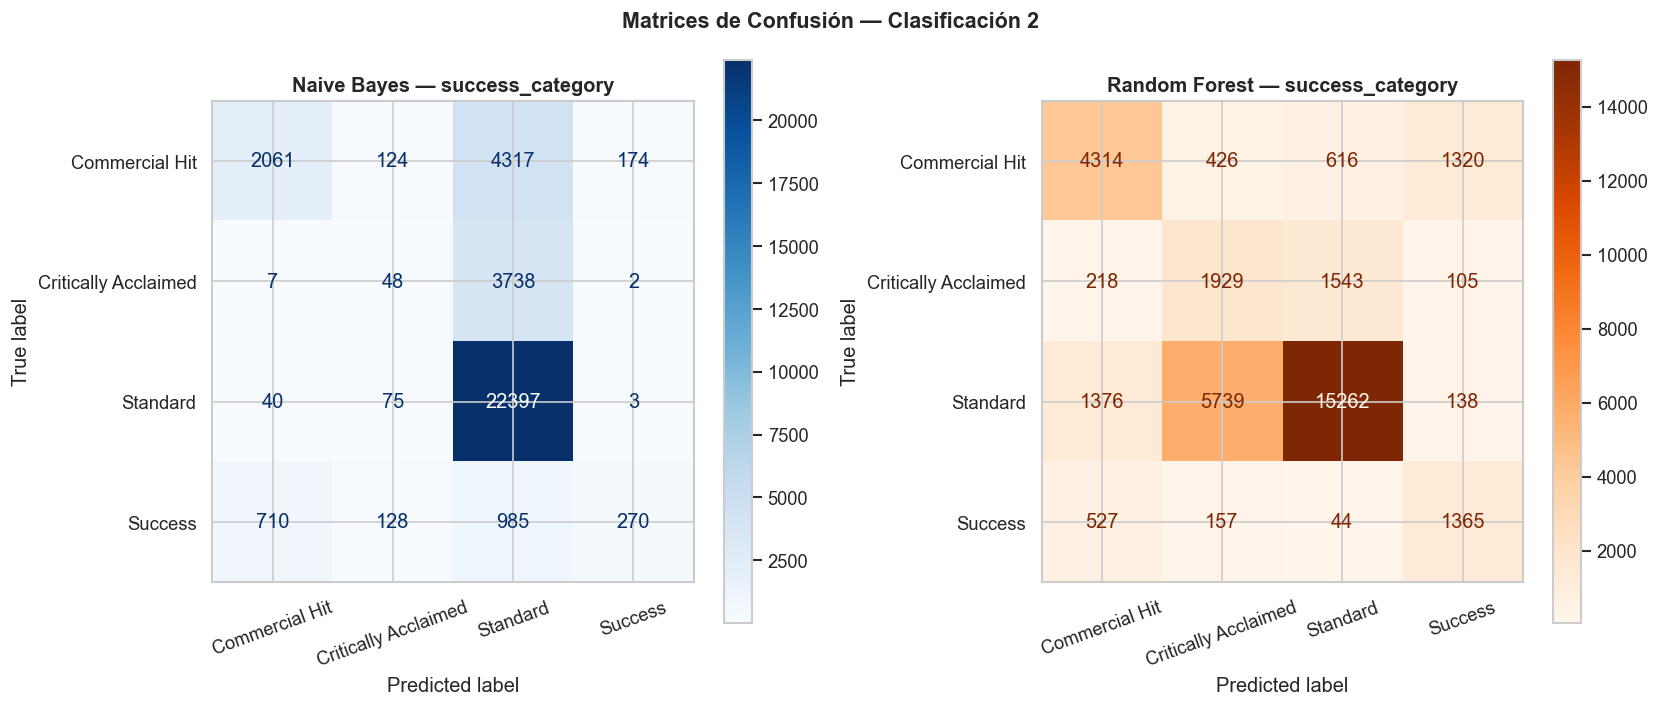


Classification Report — Naive Bayes:
                      precision    recall  f1-score   support

      Commercial Hit       0.73      0.31      0.43      6676
Critically Acclaimed       0.13      0.01      0.02      3795
            Standard       0.71      0.99      0.83     22515
             Success       0.60      0.13      0.21      2093

            accuracy                           0.71     35079
           macro avg       0.54      0.36      0.37     35079
        weighted avg       0.65      0.71      0.63     35079


Classification Report — Random Forest:
                      precision    recall  f1-score   support

      Commercial Hit       0.67      0.65      0.66      6676
Critically Acclaimed       0.23      0.51      0.32      3795
            Standard       0.87      0.68      0.76     22515
             Success       0.47      0.65      0.54      2093

            accuracy                           0.65     35079
           macro avg       0.56      0.62      0.

In [29]:
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X, y2_enc, test_size=0.3, random_state=42, stratify=y2_enc
)

nb2_vis = GaussianNB().fit(X_tr2, y_tr2)
y_pred_nb2 = nb2_vis.predict(X_te2)

rf2_vis = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
).fit(X_tr2, y_tr2)
y_pred_rf2 = rf2_vis.predict(X_te2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(
    y_te2, y_pred_nb2,
    display_labels=CLASS_NAMES,
    cmap='Blues', ax=axes[0], xticks_rotation=20
)
axes[0].set_title('Naive Bayes — success_category', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_te2, y_pred_rf2,
    display_labels=CLASS_NAMES,
    cmap='Oranges', ax=axes[1], xticks_rotation=20
)
axes[1].set_title('Random Forest — success_category', fontweight='bold')

plt.suptitle('Matrices de Confusión — Clasificación 2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report — Naive Bayes:")
print(classification_report(y_te2, y_pred_nb2, target_names=CLASS_NAMES))

print("\nClassification Report — Random Forest:")
print(classification_report(y_te2, y_pred_rf2, target_names=CLASS_NAMES))

C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(



Red Bayesiana — success_category (muestra 5,000):
   Accuracy    : 0.2030
   Precision   : 0.0412
   Recall      : 0.2030
   F1-Score    : 0.0685


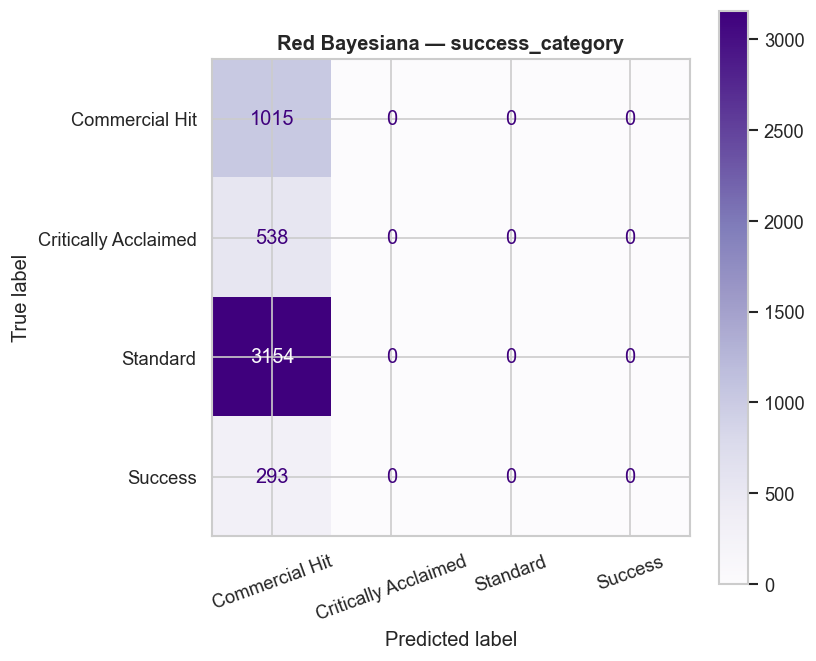

In [31]:
disc2 = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
X_disc2 = disc2.fit_transform(X).astype(int)

df_bn2 = pd.DataFrame(X_disc2, columns=[f'{c}_bin' for c in FEATURES])
df_bn2['success_category'] = y2_enc

estructura_bn2 = [
    ('vote_count_bin',   'success_category'),
    ('runtime_bin',      'success_category'),
    ('release_year_bin', 'success_category'),
    ('adult_int_bin',    'success_category'),
    ('lang_encoded_bin', 'success_category'),
    ('vote_count_bin',   'release_year_bin'),
]

bn2 = DiscreteBayesianNetwork(estructura_bn2)
bn2.fit(df_bn2, estimator=DiscreteMLE())
infer2 = VariableElimination(bn2)

y_pred_bn2_raw = predecir_bn(infer2, FEATURES, X_disc2[idx_s], 'success_category')
y_s2 = y2_enc[idx_s]

res_bn2 = {
    'Modelo':    'Red Bayesiana — success_category',
    'Accuracy':  round(accuracy_score(y_s2,  y_pred_bn2_raw), 4),
    'Precision': round(precision_score(y_s2, y_pred_bn2_raw,
                        average='weighted', zero_division=0), 4),
    'Recall':    round(recall_score(y_s2,    y_pred_bn2_raw,
                        average='weighted', zero_division=0), 4),
    'F1-Score':  round(f1_score(y_s2,        y_pred_bn2_raw,
                        average='weighted', zero_division=0), 4),
}

print("\nRed Bayesiana — success_category (muestra 5,000):")
for k, v in res_bn2.items():
    if k != 'Modelo':
        print(f"   {k:12}: {v:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_s2, y_pred_bn2_raw,
    display_labels=CLASS_NAMES,
    cmap='Purples', ax=ax, xticks_rotation=20
)
ax.set_title('Red Bayesiana — success_category', fontweight='bold')
plt.tight_layout()
plt.show()

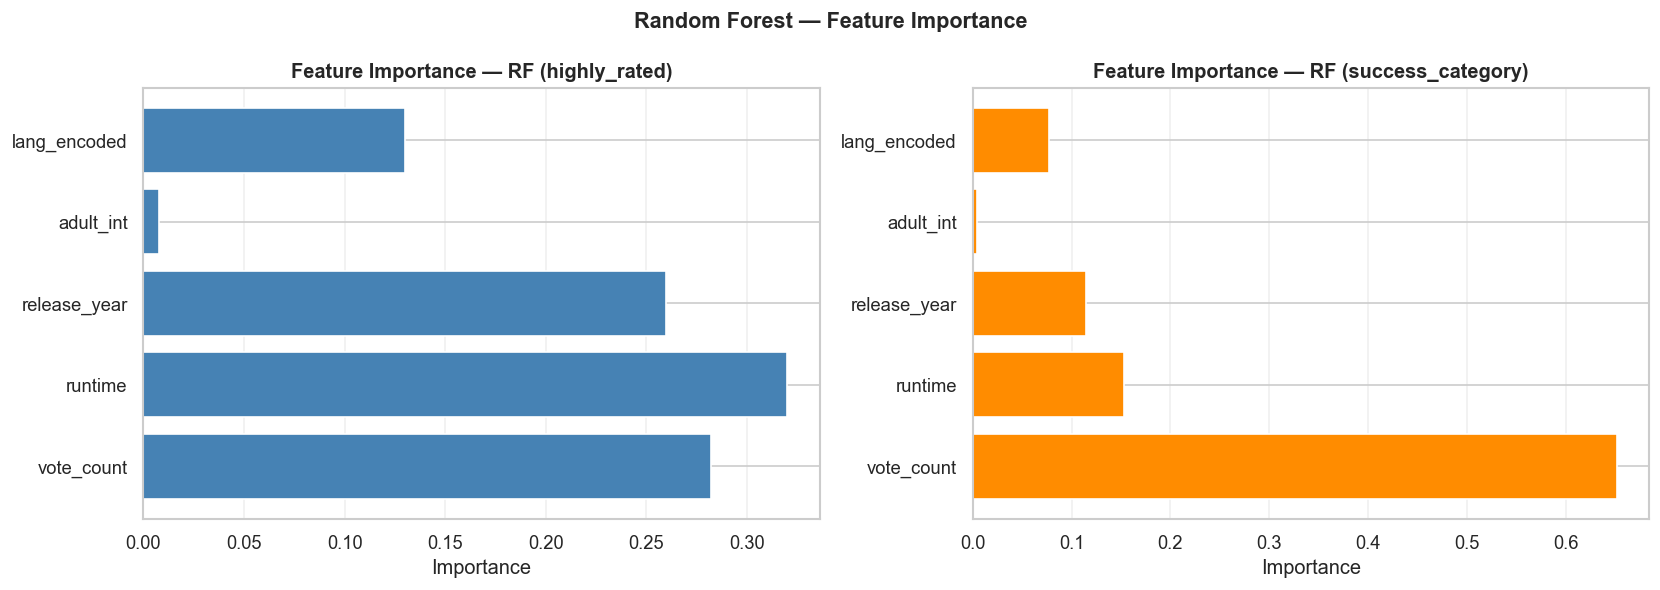

In [32]:
rf1_vis.fit(X_tr, y_tr)
rf2_vis.fit(X_tr2, y_tr2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(FEATURES, rf1_vis.feature_importances_,
             color='steelblue', edgecolor='white')
axes[0].set_title('Feature Importance — RF (highly_rated)', fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].grid(alpha=0.3, axis='x')

axes[1].barh(FEATURES, rf2_vis.feature_importances_,
             color='darkorange', edgecolor='white')
axes[1].set_title('Feature Importance — RF (success_category)', fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
todos = [
    res_nb1, res_bn1, res_rf1,
    res_nb2, res_bn2, res_rf2,
]

tabla = pd.DataFrame(todos).set_index('Modelo')

print("="*65)
print("  COMPARATIVA FINAL — CLASIFICACIÓN TMDB")
print("="*65)
display(tabla.style
        .highlight_max(color='lightgreen', axis=0)
        .highlight_min(color='#ffcccc',    axis=0)
        .format("{:.4f}"))

print("\nNota: F1-Score es la métrica principal.")
print("      Clasificación 1 usa F1 binary | Clasificación 2 usa F1 weighted.")
print("      Red Bayesiana evaluada sobre muestra de 5,000 registros.")

  COMPARATIVA FINAL — CLASIFICACIÓN TMDB


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Naive Bayes — highly_rated,0.8285,0.4307,0.0673,0.1163
Red Bayesiana — highly_rated,0.8338,0.0000,0.0000,0.0000
Random Forest — highly_rated,0.7390,0.3378,0.5770,0.4261
Naive Bayes — success_category,0.7014,0.6398,0.7014,0.6220
Red Bayesiana — success_category,0.2030,0.0412,0.2030,0.0685
Random Forest — success_category,0.6477,0.7405,0.6477,0.6789



Nota: F1-Score es la métrica principal.
      Clasificación 1 usa F1 binary | Clasificación 2 usa F1 weighted.
      Red Bayesiana evaluada sobre muestra de 5,000 registros.


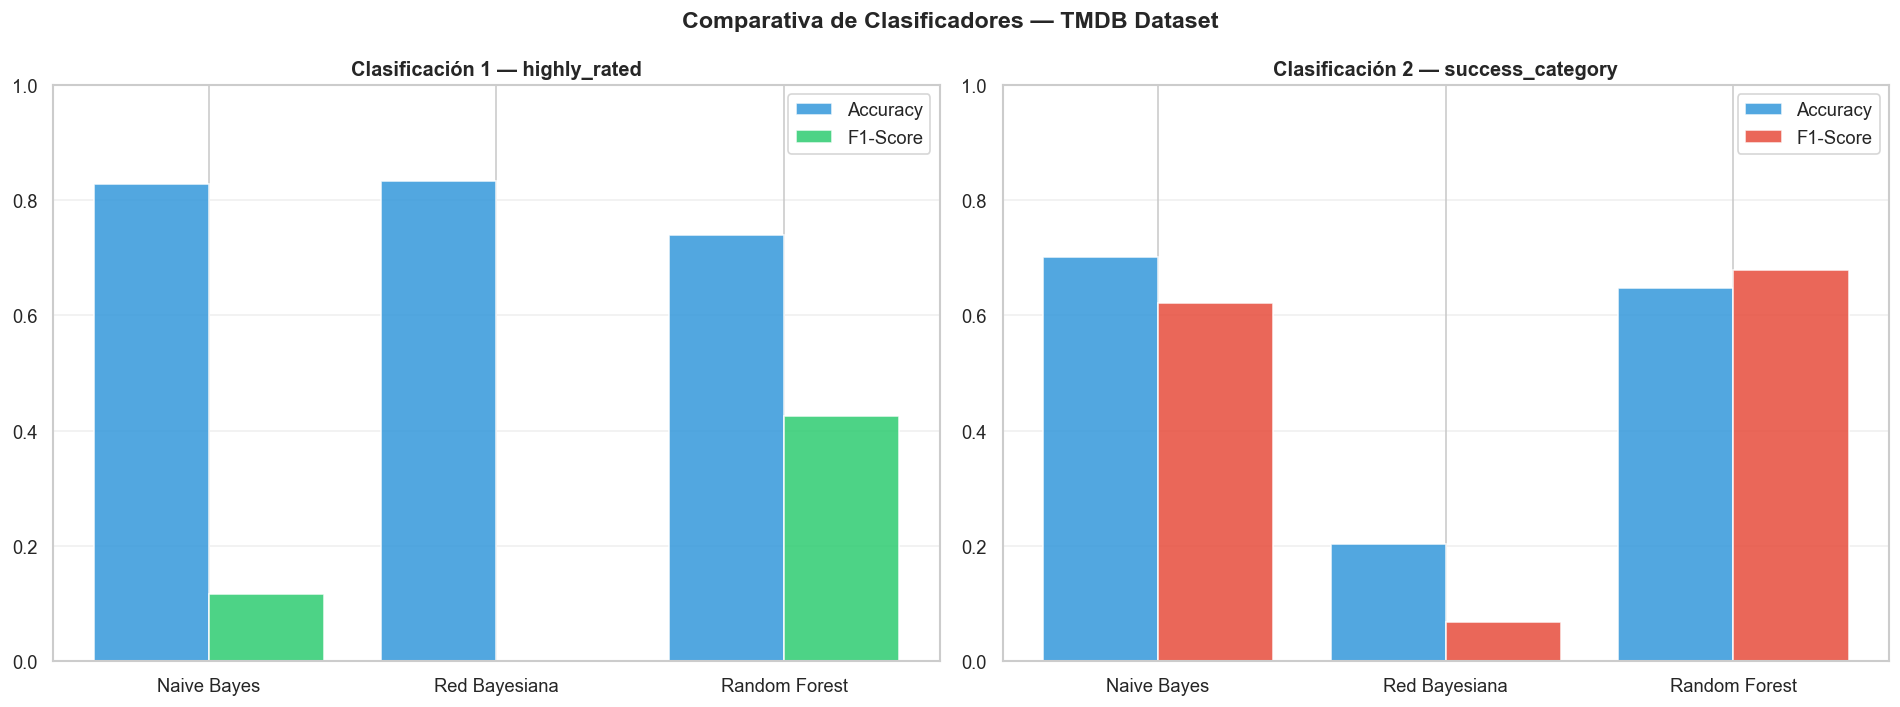

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Clasificación 1
modelos1  = ['Naive Bayes', 'Red Bayesiana', 'Random Forest']
f1_vals1  = [res_nb1['F1-Score'], res_bn1['F1-Score'], res_rf1['F1-Score']]
acc_vals1 = [res_nb1['Accuracy'], res_bn1['Accuracy'], res_rf1['Accuracy']]

x1 = np.arange(len(modelos1))
axes[0].bar(x1 - 0.2, acc_vals1, 0.4, label='Accuracy',
            color='#3498db', alpha=0.85, edgecolor='white')
axes[0].bar(x1 + 0.2, f1_vals1,  0.4, label='F1-Score',
            color='#2ecc71', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x1)
axes[0].set_xticklabels(modelos1)
axes[0].set_title('Clasificación 1 — highly_rated', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# ── Clasificación 2
modelos2  = ['Naive Bayes', 'Red Bayesiana', 'Random Forest']
f1_vals2  = [res_nb2['F1-Score'], res_bn2['F1-Score'], res_rf2['F1-Score']]
acc_vals2 = [res_nb2['Accuracy'], res_bn2['Accuracy'], res_rf2['Accuracy']]

x2 = np.arange(len(modelos2))
axes[1].bar(x2 - 0.2, acc_vals2, 0.4, label='Accuracy',
            color='#3498db', alpha=0.85, edgecolor='white')
axes[1].bar(x2 + 0.2, f1_vals2,  0.4, label='F1-Score',
            color='#e74c3c', alpha=0.85, edgecolor='white')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(modelos2)
axes[1].set_title('Clasificación 2 — success_category', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Comparativa de Clasificadores — TMDB Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()